# MA934: Assignment 1
Author: Jabir Hussain (2007942)

Firstly, we import modules necessary for this project.

In [ ]:
import random # random number generation
import numpy as np # numerical operations
import matplotlib.pyplot as plt # plotting library
import time # execution time measurement
import csv # read/write csv files
import pathlib # file path for saving time results

For both tasks 1 and 2, intermediate outputs can highlight whether a sorting algorithm has worked by inspection. The `test_sorting_algorithm` method generates random data and checks whether the given sorting algorithm's output matches that of Python's built-in sorting function. It has parameters `trials` (number of iterations), `array_size`, and `verbose`. `verbose` is defaulted to False; when set to True, it prints intermediary steps to highlight the algorithmic outputs.

In [2]:
def test_sorting_algorithm(sort_function, trials=5, array_size=10, verbose=False):
    for _ in range(trials):
        generated_data = random.sample(range(1,200), array_size)
        sorted_data = sorted(generated_data)
        original_data = generated_data.copy()
        sort_function(generated_data) # sorts values in-place, no need for new var.

        if verbose:
            print(f"Testing {sort_function.__name__}:")
            print(f"Original: {original_data}")
            print(f"Expected (using built-in sort): {sorted_data}")
            print(f"Result: {generated_data}")
            
        assert generated_data == sorted_data, f"{sort_function.__name__} sort unsuccessful."
        return f"{sort_function.__name__} sort successful."

## Task 1: Insertion Sort

The insertion sort algorithm is an $O(n^2)$ sorting algorithm. It works by maintaing a sorted subarray. To begin with, a subarray with a single item is assumed sorted. For each element in the original list, it is iteratively compared backwards with each element in the subarray. Once the correct position is found, each subarray entry larger than the element is shifted one place to the right. The use of the `gap` parameter is explored further in Task 2.

In [3]:
def insertion_sort(array, gap=1):
    for i in range(gap, len(array)):
        element = array[i]
        j = i - gap
        while j >= 0 and array[j] > element:
            array[j + gap] = array[j]
            j -= gap
        array[j + gap] = element
    return array


Test the functionality of the insertion sort solution with the helper function.

In [4]:
test_sorting_algorithm(insertion_sort)

'insertion_sort sort successful.'

## Task 2: Shell sort

The Shell sort algorithm builds on the insertion sort algorithm. Rather than comparing adjacent elements in a contiguous subarray, the Shell sort creates subarrays divided by some value $i$, referred to as the gap. This splits the array into subarrays whose elements are $i$ positions apart. These subarrays are sorted using insertion sort, the gap is reduced until it reaches 1, where a final insertion sort yields a final sorted array. The idea is that with each gap sequence, the elements are either in-place or closer to their sorted position offering an improvement in sorting performance.

In the insertion sort implementation in Task 1, the `gap` parameter was included so that the insertion sort method could be used for each gap defined in a given gap sequence. The function argument `gaps_function` determines which of the three defined gap sequences will be used for the Shell sort.
-   `half` (Shell, 1959): $h_k = \lfloor N / 2^k \rfloor$
-   `knuth` (Knuth, 1973): $h_k = \frac{(3^k - 1)}{2}$
-   `sedgewick` (Sedgewick, 1982): $h_k = 4^k + 3\times2^{k-1} + 1$

In [5]:
def shell_sort(array, gaps_function="half"):
    n = len(array)
    match gaps_function:
        case "half":
            gap_sequence = [n//(2**k) for k in range(1, int(np.log2(n)) + 1)]

        case "knuth":
            gap_sequence = [((3**k)-1) // 2 for k in range(1, 31) if ((3**k)-1)//2 < n//3]
            gap_sequence = gap_sequence[::-1] if gap_sequence else [1]

        case "sedgewick":
            gap_sequence = [4**k + 3*(2**(k-1)) + 1 if k > 0 else 1 for k in range(0, 20)]
            gap_sequence = [gap for gap in gap_sequence if gap < n][::-1] or [1]

        case _:
            raise ValueError("Invalid gap sequence function specified. Choose from 'half', 'knuth', or 'sedgewick'.")

    for gap in gap_sequence:
        insertion_sort(array, gap=gap)

    return array

The time complexity of a Shell sort implementation is contingent on the gap sequence size. 

| Gap sequence | Average case time complexity|
|:-----------------|:----------------:|
| Half (Shell, 1959) | $O(n^{3/2})$ |
| Knuth (1973) | $O(n^{3/2})$ |
| Sedgewick (1982) | $O(n^{4/3})$ |


## Task 3 - Runtime

This task meaures the runtime of both sorting algorithms for random arrays of integers of length $2^5$ to $2^{20}$. The `runtime` function accepts two arguments: `sorting_function` (sorting function to be tested) and `n` (size of input array). For each function call, the `random.sample` function is called to generate an array of `n` unique integers. It starts a counter and calculates the time elapsed by calculating the difference in start and end times.

The `sizes` array calculates values from $2^5$ to $2^{17}$. Whilst the assignment brief specifies it should go up to $2^{20}$, the computational resources required is vast. I left my laptop to execute the program for over 3 hours with no final results, so following the advice given on the module forum, I reduced the size. Each element in `sizes` is iterated across and used for each sorting algorithm.

Given the nature of the Shell sort implementation, lambda functions are used to create anonymous functions for each gap sequencing method. This means that functions would not have to be redefined, helping with readability. 

The data is then written to a CSV file in the working directory.

In [7]:
def runtime(sorting_function, n):
    generated_data = random.sample(range(1, 10_000_000), n)
    t0 = time.perf_counter()
    sorting_function(generated_data)
    return time.perf_counter() - t0

sizes = [2**k for k in range(5, 18)]
records = []

for n in sizes:
    print(f"Running n={n}")
    t_insertion_sort = runtime(insertion_sort, n)
    t_shellsort_half = runtime(lambda a: shell_sort(a, "half"), n)
    t_shellsort_knuth = runtime(lambda a: shell_sort(a, "knuth"), n)
    t_shellsort_sedgewick = runtime(lambda a: shell_sort(a, "sedgewick"), n)
    t_builtin = runtime(sorted, n)
    records.append([n, t_insertion_sort, t_shellsort_half, t_shellsort_knuth, t_shellsort_sedgewick, t_builtin])

out_path = pathlib.Path("ma934_assignment1_runtime_2007942.csv")
with out_path.open("w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["n","insertion","shell_halving","shell_knuth","shell_sedgewick","builtin"])
    w.writerows(records)
print(f"Runtime data written to {out_path.resolve()}")
    

Running n=32
Running n=64
Running n=128
Running n=256
Running n=512
Running n=1024
Running n=2048
Running n=4096
Running n=8192
Running n=16384
Running n=32768
Running n=65536
Running n=131072
Runtime data written to /Users/jabir/Documents/pmsc/MA934 - Numerical Algos and Optimisation/assignments/assignment-1/ma934_assignment1_runtime_2007942.csv


## Task 4: Empirical Analysis of Computational Complexity

The data from Task 3 was saved to a CSV file. The runtime efficiency of each sorting algorithm can be visualised with a graphical plot. Using the `genfromtxt` function in the `numpy` library, we can import the saved data into a numpy array and extract the values by column.

In [ ]:
file = "ma934_assignment1_runtime_2007942.csv"
runtime_data = np.genfromtxt(file, delimiter=",", names=True)

n = runtime_data["n"]
insertion = runtime_data["insertion"]
shell_halving = runtime_data["shell_halving"]
shell_knuth = runtime_data["shell_knuth"]
shell_sedgewick = runtime_data["shell_sedgewick"]
builtin = runtime_data["builtin"]

The plot uses a log-log scale given the sheer size of data, whilst showing how computational cost is in proportion to an input array's size. 

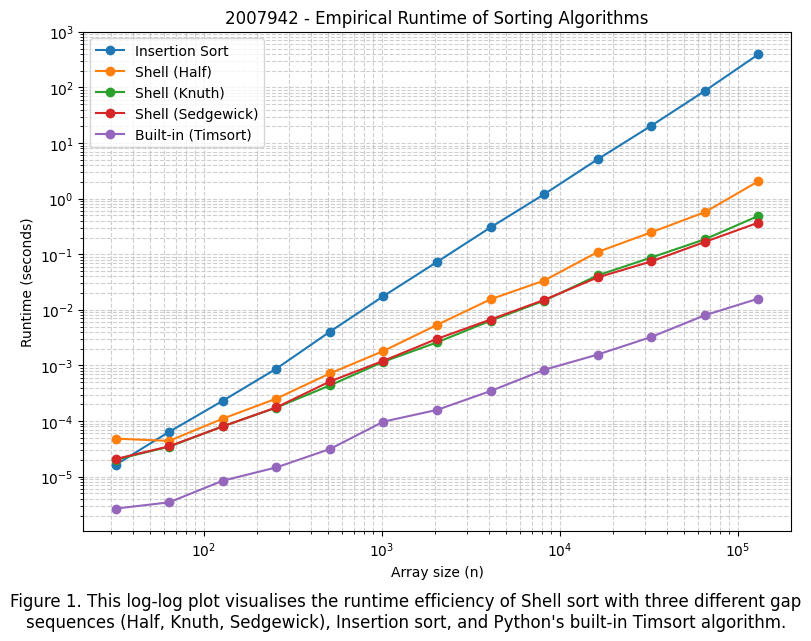

In [13]:
plt.figure(figsize=(8,6))
plt.loglog(n, insertion, "o-", label="Insertion Sort")
plt.loglog(n, shell_halving, "o-", label="Shell (Half)")
plt.loglog(n, shell_knuth, "o-", label="Shell (Knuth)")
plt.loglog(n, shell_sedgewick, "o-", label="Shell (Sedgewick)")
plt.loglog(n, builtin, "o-", label="Built-in (Timsort)")

fig1="Figure 1. This log-log plot visualises the runtime efficiency of Shell sort with three different gap sequences (Half, Knuth, Sedgewick), Insertion sort, and Python's built-in Timsort algorithm."
plt.figtext(0.5, -0.05, fig1, wrap=True, ha='center', fontsize=12)
plt.xlabel("Array size (n)")
plt.ylabel("Runtime (seconds)")
plt.title("2007942 - Empirical Runtime of Sorting Algorithms")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

The log-log plot highlights the following behaviour:
* Insertion sort is the most computationally expensive sorting algorithm used for this investigation as it has the steepest slope, demonstrating its $O(n^2)$ time complexity.
* Shell sort with halving gap sequences shows a considerable improvement on the vanilla insertion sort algorithm, with a shallower slope.
* Interestingly, both Knuth's and Sedgewick's gap sequencing formulae yielded identical runtime results across all array sizes. Knuth's gap sequencing has a worst-case time complexity of $O(n^{\frac{3}{2}})$ whereas Sedgewick's has a worst-case time complexity of $O(n^{\frac{4}{3}})$. One would assume the margin between their performances would be larger, however this empirical study shows a near identical performance.
* Python's built-in Timsort displays near linear-logarithmic performance, demonstrating $O(n\log n)$ performance.

## Task 5: Big O Mathematics
In this exercise, for each function's Taylor expansion, we find the largest power $p$ as $h \rightarrow 0$.

Question 1: $\sin(h)$

We find the Taylor expansion of the function is as follows:

$$\sin(h) = h - \frac{h^3}{3!} + \frac{h^5}{5!} - \frac{h^7}{7!}$$


As $h \rightarrow 0, \sin(h) \approx h$, thus $\sin(h) = O(h)$ and $p=1$


Question 2: $\cos(h) - 1$

Firstly, we find the Taylor expansion of $\cos(h)$.

$$\cos(h) = 1 - \frac{h^2}{2} + \frac{h^4}{4!} - \frac{h^6}{6!}$$
$$\cos(h) - 1 = - \frac{h^2}{2} + \frac{h^4}{4!} - \frac{h^6}{6!}$$

As $h \rightarrow 0, \cos(h) - 1 \approx -\frac{h^2}{2}$. Thus, $\cos(h) - 1 = O(h^2)$ and $p=2$.

Question 3: $exp(h) - h$

Using the Taylor expansion of $e^h,$ we get:

$$\exp(h) = 1 + h + \frac{h^2}{2!} + \frac{h^3}{3!} + ...$$
$$\exp(h) - h = 1 + \frac{h^2}{2!} + \frac{h^3}{3!} + ...$$

As $h \rightarrow 0, \exp(h) - h \approx 1 + \frac{h^2}{2}$. Thus, $\exp(h) - h = 1 + O(h^2)$ and $p=2$.

## Task 6: Difference Equations Mathematics

This exercise focuses on the difference equation: $$y_{k+2} - 3y_{k+1} - 4y_k = f(k)$$ with initial conditions $y_0=3, y_1=2$.

**Question 1:** order of the difference equation.

The order of the difference equation is 2, as it is the largest index ($k+2$) from $k$.


**Question 2:** solve for the homogenous equation $f(k) = 0$. $$ y_{k+2} - 3y_{k+1} - 4y_k = 0$$. Using a general solution in the form $y_k = m^k$, we can substitute it into homogenous equation, yielding 
$$m^{k+2} - 3m^{k+1} - 4m^k - 0 \implies m^2 - 3m - 4 = 0.$$

Factorising and solving the characteristic equation gives $$m^2 - 3m - 4 = (m-4)(m+1) = 0 \implies m_1 = 4, m_2 = -1$$

This gives the general homogenous solution $$y_k = A \cdot 4^k + B \cdot (-1)^k$$.
Using the initial conditions for $k = 0, k = 1$ we find the following:
$$ y_0 = A \cdot 4^0 + B \cdot (-1)^0 = A+B = 3 $$
$$ y_1 = A \cdot 4^1 + B \cdot (-1)^1 = 4A - B = 2 $$

Substituting and solving gives $$ B = 3-A $$ $$ 4A - (3-A) = 2 \implies 5A = 5 \implies A = 1 \implies B = 2$$

Thus we find that $A = 1, B = 2$, with the final solution $$y_k = 4^k + 2(-1)^k$$.


**Question 3:** solve for inhomogenous equation $f(k) = 5$.
$$ y_{k+2} - 3y_{k+1} - 4y_k = 5$$
As $f(k) = \text{constant}$, we use a constant particular solution. We set $y_k = C$ and find that $$C - 3C - 4C = 5 \implies -6C = 5 \implies C = -\frac{5}{6}$$, giving a particular solution as $y_k = -\frac{5}{6}$. 

The general inhomogenous solution is the sum of the particular solution and general homogenous solution:
$$ y_k = -\frac{5}{6} + A \cdot 4^k + B \cdot (-1)^k.$$

Using the initial conditions $y_0$ and $y_1$, we find that

$$ -\frac{5}{6} + A + B = 3 \implies A+B = \frac{23}{6} $$
$$ -\frac{5}{6} + 4A - B = 2 \implies 4A - B = \frac{17}{6} $$

Substituting and solving gives $$4A - (\frac{23}{6} - A) = \frac{17}{6} \implies 30A = 40 \implies A = \frac{4}{3}, B = \frac{5}{2}$$.

Thus, the final solution takes the form $$y_k = \frac{4}{3}\cdot 4^k + \frac{5}{2}(-1)^k - \frac{5}{6}.$$